In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from torch.utils.data import Dataset, DataLoader
from source.model.memory import MemoryContinuous

In [2]:
def generate_seq(total_samples, vocab=10):
    return torch.arange(total_samples)%vocab

In [3]:
class DatasetConverter(Dataset):
    def __init__(self, data, working_memory=1, short_term_memory=3):
        self.X = torch.zeros((len(data)-working_memory-short_term_memory, short_term_memory), dtype=torch.int64)
        for i in range(self.X.shape[0]):
            for j in range(self.X.shape[1]):
                self.X[i, j] = data[i+j]

        self.X = torch.tensor(self.X).long()

    def __getitem__(self, idx):
        return self.X[idx]

    def __len__(self):
        return self.X.shape[0]

In [85]:
torch.manual_seed(0)
random.seed(0)

vocab_size = 10
seq_len = 3
hidden_size = 30
num_epochs = 20
total_samples = 1000

model = MemoryContinuous(
    input_size=vocab_size,
    hidden_size=hidden_size,
    embedding_dim=3,
    tau=.1
)

sequence = generate_seq(total_samples, vocab_size)
dataset = DatasetConverter(sequence)
loader = DataLoader(dataset, batch_size=1, shuffle=False)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

lambda_cont = 1   # continuity strength

h = None
h_prev = None   # store previous hidden state
for epoch in range(num_epochs):
    for x in loader:
        logits, h_ = model(x, h)

        # -------- reconstruction loss --------
        #print(logits[:, 2], x[:, seq_len-2-1])
        recon_loss = sum(
            criterion(logits[:, t], x[:, seq_len-t-1]) for t in range(seq_len)
        ) / seq_len

        # -------- continuity regularizer --------
        if h_prev is None:
            cont_loss = torch.tensor(0.0, device=logits.device)
        else:
            cont_loss = torch.mean((h_ - h_prev) ** 2)

        loss = recon_loss + lambda_cont * cont_loss

        if loss > 1e-4:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # update hidden states
        h_prev = h_.detach()
        h = h_.detach()

    print(
        f"Epoch {epoch}: "
        f"recon={recon_loss.item():.4f}, "
        f"cont={cont_loss.item():.4f}"
    )


/var/folders/_7/jy1bxm8x25zgqldfzz7cqv8r0000gn/T/ipykernel_47888/4104037018.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X = torch.tensor(self.X).long()


Epoch 0: recon=0.0513, cont=0.1243
Epoch 1: recon=0.0200, cont=0.0657
Epoch 2: recon=0.0118, cont=0.0427
Epoch 3: recon=0.0073, cont=0.0284
Epoch 4: recon=0.0049, cont=0.0210
Epoch 5: recon=0.0033, cont=0.0159
Epoch 6: recon=0.0025, cont=0.0120
Epoch 7: recon=0.0012, cont=0.0097
Epoch 8: recon=0.0013, cont=0.0086
Epoch 9: recon=0.0010, cont=0.0066
Epoch 10: recon=0.0007, cont=0.0053
Epoch 11: recon=0.0007, cont=0.0042
Epoch 12: recon=0.0005, cont=0.0059
Epoch 13: recon=0.0006, cont=0.0050
Epoch 14: recon=0.0006, cont=0.0042
Epoch 15: recon=0.0005, cont=0.0040
Epoch 16: recon=0.0005, cont=0.0038
Epoch 17: recon=0.0005, cont=0.0037
Epoch 18: recon=0.0006, cont=0.0057
Epoch 19: recon=0.0006, cont=0.0049


tensor([[0, 1, 2]])
tensor([[1, 2, 3]])
tensor([[2, 3, 4]])
tensor([[3, 4, 5]])
tensor([[4, 5, 6]])
tensor([[5, 6, 7]])
tensor([[6, 7, 8]])
tensor([[7, 8, 9]])
tensor([[8, 9, 0]])
tensor([[9, 0, 1]])
tensor([[0, 1, 2]])
tensor([[1, 2, 3]])
tensor([[2, 3, 4]])
tensor([[3, 4, 5]])
tensor([[4, 5, 6]])
tensor([[5, 6, 7]])
tensor([[6, 7, 8]])
tensor([[7, 8, 9]])
MDS stress: 0.42875336135452874


/var/folders/_7/jy1bxm8x25zgqldfzz7cqv8r0000gn/T/ipykernel_47888/4104037018.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X = torch.tensor(self.X).long()


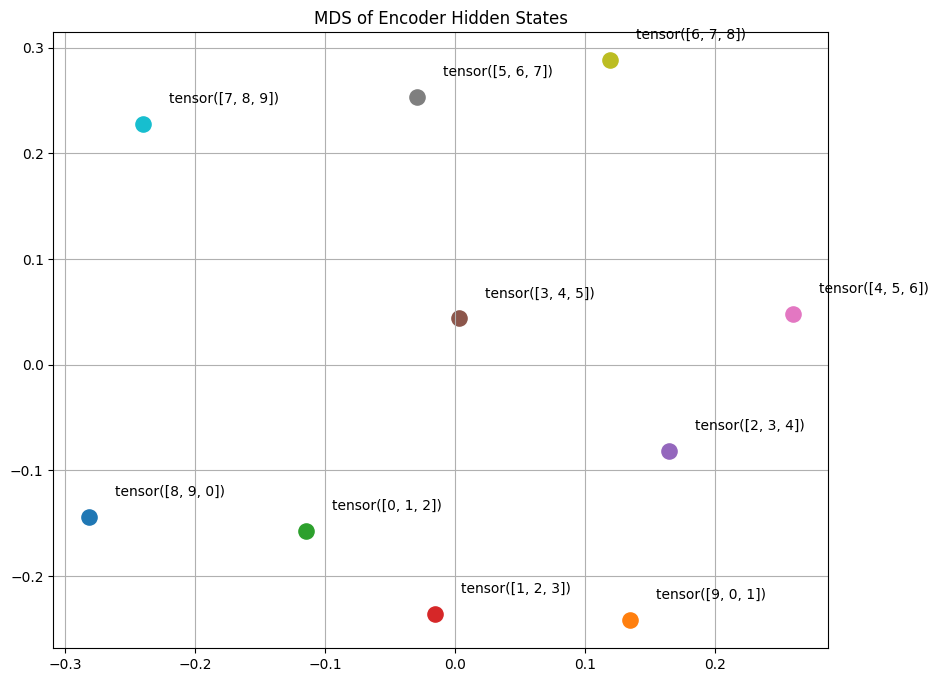

In [86]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import itertools

# Step 1: Generate the sequence
sequence = generate_seq(vocab_size+12, vocab_size)
dataset = DatasetConverter(sequence)
loader = DataLoader(dataset, batch_size=1, shuffle=False)
# Step 2–3: Run through encoder and collect hidden states
hidden_codes = []
labels = []

h = None
total = 0
model.eval()
with torch.no_grad():
    for x in loader:
        total += 1
        print(x)
        _, h = model(x, h)

        if total>8:
            hidden_codes.append(h[0].numpy())  # extract (H,) from (1,1,H)
            labels.append("".join(map(str, x)))

# Step 4: Reduce dimension
hidden_codes = torch.tensor(hidden_codes)
# Step 1: MDS projection
mds = MDS(
    n_components=2,
    random_state=420,
    dissimilarity="euclidean",  # uses Euclidean distances on hidden_codes
    normalized_stress="auto"
)

embeddings = mds.fit_transform(hidden_codes)

# Optional: report stress (lower is better)
print("MDS stress:", mds.stress_)

# Step 2: Plot
plt.figure(figsize=(10, 8))
for i, txt in enumerate(labels):
    plt.scatter(embeddings[i, 0], embeddings[i, 1], s=120)
    plt.text(
        embeddings[i, 0] + 0.02,
        embeddings[i, 1] + 0.02,
        txt,
        fontsize=10
    )

plt.title("MDS of Encoder Hidden States")
plt.grid(True)
plt.show()


In [87]:
h

tensor([[0.2399, 0.0866, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.2078, 0.1997,
         0.0000, 0.0000, 0.1487, 0.0565, 0.0000, 0.0000, 0.0000, 0.0000, 0.1757,
         0.0000, 0.0000, 0.0916, 0.0000, 0.0371, 0.0000, 0.1049, 0.0000, 0.0000,
         0.0000, 0.0678, 0.1029]])

In [88]:
hidden_codes

tensor([[0.0000, 0.2018, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1218,
         0.0000, 0.0000, 0.0000, 0.1100, 0.0000, 0.0000, 0.0063, 0.0585, 0.2173,
         0.0000, 0.0000, 0.1194, 0.0000, 0.0000, 0.0000, 0.0000, 0.2211, 0.0000,
         0.0000, 0.1087, 0.0000],
        [0.0000, 0.1616, 0.0000, 0.0000, 0.0858, 0.0000, 0.0000, 0.0866, 0.0000,
         0.0000, 0.0000, 0.1503, 0.0000, 0.0690, 0.0000, 0.0000, 0.0000, 0.2900,
         0.0707, 0.0000, 0.1371, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0284, 0.0000, 0.0000],
        [0.0000, 0.1636, 0.0000, 0.0000, 0.0000, 0.0370, 0.0000, 0.0000, 0.0274,
         0.0000, 0.0000, 0.0000, 0.1524, 0.1313, 0.0000, 0.0000, 0.0000, 0.2357,
         0.0000, 0.0000, 0.2045, 0.0000, 0.0000, 0.0059, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0819],
        [0.0806, 0.1656, 0.0000, 0.0000, 0.0000, 0.1366, 0.1161, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.1196, 0.0000, 0.0650, 0.0668, 0.2576,
       

In [89]:
hidden_codes[:,3]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

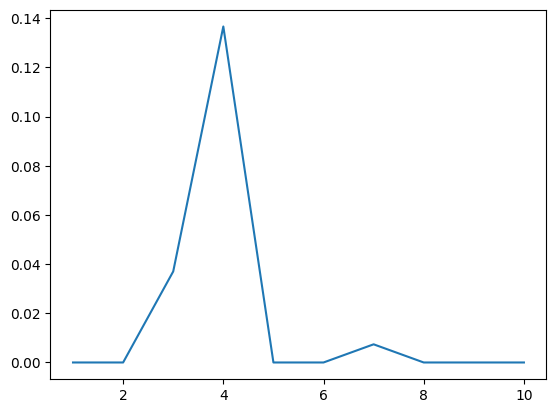

In [90]:
import numpy as np 

plt.plot(np.arange(1,11),hidden_codes[:,5])

In [77]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Example: 100 hidden states of dimension 30
# Replace this with your actual tensor
hidden_states = hidden_codes

# Parameters
window_size = 3
num_states, D = hidden_states.shape

# Prepare sliding window dataset
X = []
Y = []
for t in range(window_size, num_states):
    # concatenate last 3 hidden states
    x_window = hidden_states[t-window_size:t].reshape(-1)  # shape: 3*D
    y_target = hidden_states[t]  # next hidden state
    X.append(x_window)
    Y.append(y_target)

X = torch.stack(X)  # shape: (num_states - window_size, 3*D)
Y = torch.stack(Y)  # shape: (num_states - window_size, D)

# Linear predictor
class LinearPredictor(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)
    def forward(self, x):
        return self.linear(x)

model = LinearPredictor(input_dim=window_size*D, output_dim=D)
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

# Training loop
for epoch in range(500):  # can reduce/increase epochs
    optimizer.zero_grad()
    y_pred = model(X)
    loss = criterion(y_pred, Y)
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch}, MSE Loss: {loss.item():.6f}")

# Evaluate cosine similarity per state
with torch.no_grad():
    Y_pred = model(X)
    cos_sim = F.cosine_similarity(Y_pred, Y, dim=1)
    print(f"Average cosine similarity: {cos_sim.mean():.4f}")


Epoch 0, MSE Loss: 0.015425
Epoch 50, MSE Loss: 0.000029
Epoch 100, MSE Loss: 0.000000
Epoch 150, MSE Loss: 0.000000
Epoch 200, MSE Loss: 0.000000
Epoch 250, MSE Loss: 0.000000
Epoch 300, MSE Loss: 0.000000
Epoch 350, MSE Loss: 0.000000
Epoch 400, MSE Loss: 0.000000
Epoch 450, MSE Loss: 0.000000
Average cosine similarity: 1.0000


In [83]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Suppose hidden_states is your original tensor: shape (100, D)
hidden_states = hidden_codes  # replace with your actual tensor
D = hidden_states.shape[1]

# --- Step 1: Downsample by 3 ---
hidden_downsampled = hidden_states[::3]  # take every 3rd state
num_states_down = hidden_downsampled.shape[0]

# Parameters
window_size = 3  # last 3 states to predict next

# --- Step 2: Prepare sliding window dataset ---
X = []
Y = []
for t in range(window_size, num_states_down):
    x_window = hidden_downsampled[t-window_size:t].reshape(-1)  # shape: 3*D
    y_target = hidden_downsampled[t]  # next state
    X.append(x_window)
    Y.append(y_target)

X = torch.stack(X)  # shape: (num_states_down - window_size, 3*D)
Y = torch.stack(Y)  # shape: (num_states_down - window_size, D)

# --- Step 3: Linear predictor ---
class LinearPredictor(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)
    def forward(self, x):
        return self.linear(x)

model = LinearPredictor(input_dim=window_size*D, output_dim=D)
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

# --- Step 4: Training loop ---
for epoch in range(500):
    optimizer.zero_grad()
    y_pred = model(X)
    loss = criterion(y_pred, Y)
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch}, MSE Loss: {loss.item():.6f}")

# --- Step 5: Evaluate cosine similarity ---
with torch.no_grad():
    Y_pred = model(X)
    cos_sim = F.cosine_similarity(Y_pred, Y, dim=1)
    print(f"Average cosine similarity (downsampled): {cos_sim.mean():.4f}")


Epoch 0, MSE Loss: 0.013400
Epoch 50, MSE Loss: 0.000025
Epoch 100, MSE Loss: 0.000000
Epoch 150, MSE Loss: 0.000000
Epoch 200, MSE Loss: 0.000000
Epoch 250, MSE Loss: 0.000000
Epoch 300, MSE Loss: 0.000000
Epoch 350, MSE Loss: 0.000000
Epoch 400, MSE Loss: 0.000000
Epoch 450, MSE Loss: 0.000000
Average cosine similarity (downsampled): 1.0000
